## COVID Drivers: Modeling

This notebook models POST_COVID ~ NHTSA_AGG_DRIVING

### Table of Contents
* [Read the Data](#read)</BR>
* [Preprocessing](#prep)</BR>
* [Random Forest Classifier](#rfc)</BR>
* [Random Forest Classifier with GridSearchCV](#rf-gs)
* [Review Models](#review)


Import packages

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
import os

import xgboost as xgb
from functools import reduce
#import prince

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path_in = '/content/drive/MyDrive/Colab Notebooks/Case Studies in Data Science/data/ready/ready_data_final.csv'

In [ ]:
path_out = 'metrics_07_prim_modl_rf.csv'

### <a id='read'>Read the data</a>

In [ ]:
df_init = pd.read_csv(path_in, low_memory=False)

In [ ]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [ ]:
df = df_init.set_index('CRASH_DATE').drop(columns=['CRN']).copy()

In [ ]:
model_metrics = []

In [ ]:
df.columns.tolist()

['URBAN_RURAL',
 'POST_COVID',
 'AGGRESSIVE_DRIVING',
 'CELL_PHONE',
 'DISTRACTED',
 'NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING']

### <a id='prep'>Preprocessing</a>

In [ ]:
X = df.loc[:,['POST_COVID']].copy()

In [ ]:
y = df['NHTSA_AGG_DRIVING']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
categorical_cols = ['URBAN_RURALx']

In [ ]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols)
    ])

### <a id='rfc'>Random Forest Classifier</a>

In [ ]:
rf_pipeline = Pipeline(steps=[
    #('preprocessor', preprocessor),
    ('random_forest', RandomForestClassifier(class_weight='balanced_subsample', random_state=42))
])

In [ ]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('random_forest',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        random_state=42))])

In [ ]:
y_pred = rf_pipeline.predict(X_test)


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 75.22%


In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)

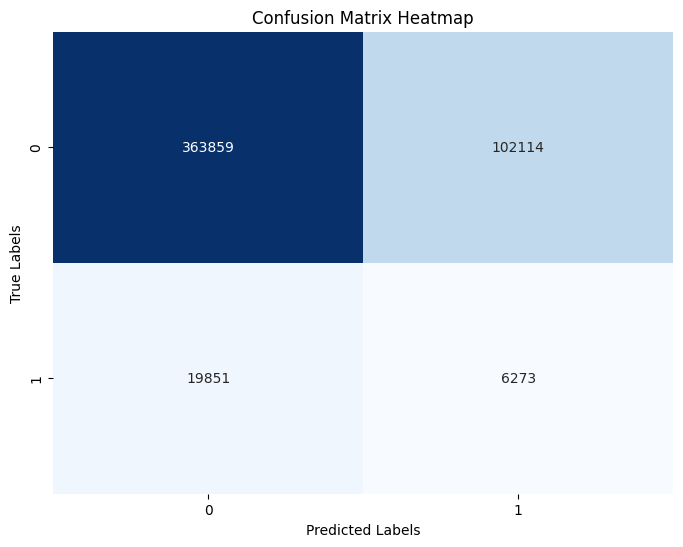

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
# Predicted probabilities for the class 1
y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [ ]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [ ]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [ ]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [ ]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'RandomForestClassifier'

In [ ]:
aggdrv_rf = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [ ]:
aggdrv_rf['RandomForestClassifier'] = [round(x, 4) for x in aggdrv_rf['RandomForestClassifier']]

In [ ]:
aggdrv_rf

,Measure,RandomForestClassifier
0,Accuracy,0.7522
1,Precision,0.0579
2,Recall,0.2401
3,F1 Score,0.0933
4,ROC AUC,0.5105


In [ ]:
model_metrics.append(aggdrv_rf)

In [ ]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.78      0.86    465973
           1       0.06      0.24      0.09     26124

    accuracy                           0.75    492097
   macro avg       0.50      0.51      0.47    492097
weighted avg       0.90      0.75      0.82    492097



### <a id='rf-gs'>Random Forest Classifier with GridSearchCV</a>

In [ ]:
rf = RandomForestClassifier(class_weight='balanced_subsample', random_state=42)

In [ ]:
param_grid = {
    #'n_estimators': [50, 100],
    #'n_estimators': [50, 70],
    'n_estimators': [25, 50],
    'max_depth': [None, 5],
    'min_samples_split': [2, 5, 8]
}

In [ ]:
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=10, scoring='f1', refit=True)

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=RandomForestClassifier(class_weight='balanced_subsample',
                                              random_state=42),
             param_grid={'max_depth': [None, 5], 'min_samples_split': [2, 5, 8],
                         'n_estimators': [25, 50]},
             scoring='f1')

In [ ]:
grid_search.best_params_

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 25}

In [ ]:
y_pred = grid_search.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 75.22%


In [ ]:
# Predicted probabilities for the class 1
y_pred_proba = grid_search.predict_proba(X_test)[:, 1]

In [ ]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [ ]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [ ]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [ ]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [ ]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'RandomForestClassifier_GridSearchCV'

In [ ]:
aggdrv_rfcv = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [ ]:
aggdrv_rfcv['RandomForestClassifier_GridSearchCV'] = [round(x, 4) for x in aggdrv_rfcv['RandomForestClassifier_GridSearchCV']]

In [ ]:
aggdrv_rfcv

,Measure,RandomForestClassifier_GridSearchCV
0,Accuracy,0.7522
1,Precision,0.0579
2,Recall,0.2401
3,F1 Score,0.0933
4,ROC AUC,0.5105


In [ ]:
model_metrics.append(aggdrv_rfcv)

In [ ]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.78      0.86    465973
           1       0.06      0.24      0.09     26124

    accuracy                           0.75    492097
   macro avg       0.50      0.51      0.47    492097
weighted avg       0.90      0.75      0.82    492097



### <a id='review'>Review Models</a>

In [ ]:
merged_metrics = reduce(lambda left, right: pd.merge(left, right, on='Measure', how='inner'), model_metrics)

In [ ]:
merged_metrics

,Measure,RandomForestClassifier,RandomForestClassifier_GridSearchCV
0,Accuracy,0.7522,0.7522
1,Precision,0.0579,0.0579
2,Recall,0.2401,0.2401
3,F1 Score,0.0933,0.0933
4,ROC AUC,0.5105,0.5105


In [ ]:
merged_metrics.to_csv(path_out, index=False)